In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

root_dir = "/content/drive/MyDrive/Dissertation_Dataset/database_nifti"
print("Exists?", os.path.exists(root_dir))
print("First 20 items:", os.listdir(root_dir)[:20])

Exists? True
First 20 items: ['LICENSE_TERMS.md', 'patient0006', 'patient0004', 'patient0007', 'patient0001', 'patient0002', 'patient0005', 'patient0010', 'patient0009', 'patient0003', 'patient0008', 'patient0011', 'patient0012', 'patient0016', 'patient0020', 'patient0014', 'patient0017', 'patient0013', 'patient0019', 'patient0018']


In [ ]:
!pip -q install nibabel segmentation-models-pytorch albumentations torchmetrics medpy

In [ ]:
import glob
import random
import numpy as np
import pandas as pd
import nibabel as nib
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from medpy.metric.binary import hd95

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Tesla T4 safe defaults
IMAGE_SIZE = 256
BATCH_SIZE = 4
LR = 1e-4
NUM_CLASSES = 4  # 0=BG, 1=LV, 2=MYO, 3=LA

Device: cuda


In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
cv2.setNumThreads(0)
torch.set_num_threads(1)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("Thread + cuDNN safe settings applied.")

Thread + cuDNN safe settings applied.


In [ ]:
def get_patient_dirs(root_dir):
    return sorted([
        d for d in os.listdir(root_dir)
        if d.startswith("patient") and os.path.isdir(os.path.join(root_dir, d))
    ])

def get_image_mask_pairs(root_dir):
    images, masks = [], []
    patient_dirs = get_patient_dirs(root_dir)

    for p in patient_dirs:
        p_path = os.path.join(root_dir, p)

        for view in ["2CH", "4CH"]:
            for phase in ["ED", "ES"]:
                img = glob.glob(os.path.join(p_path, f"*_{view}_{phase}.nii.gz"))
                gt  = glob.glob(os.path.join(p_path, f"*_{view}_{phase}_gt.nii.gz"))

                if img and gt:
                    images.append(img[0])
                    masks.append(gt[0])

    return images, masks

patient_dirs = get_patient_dirs(root_dir)
images, masks = get_image_mask_pairs(root_dir)

print("Patient folders:", len(patient_dirs))
print("Total image-mask pairs:", len(images))
print("Example image:", images[0])
print("Example mask :", masks[0])

Patient folders: 500
Total image-mask pairs: 2000
Example image: /content/drive/MyDrive/Dissertation_Dataset/database_nifti/patient0001/patient0001_2CH_ED.nii.gz
Example mask : /content/drive/MyDrive/Dissertation_Dataset/database_nifti/patient0001/patient0001_2CH_ED_gt.nii.gz


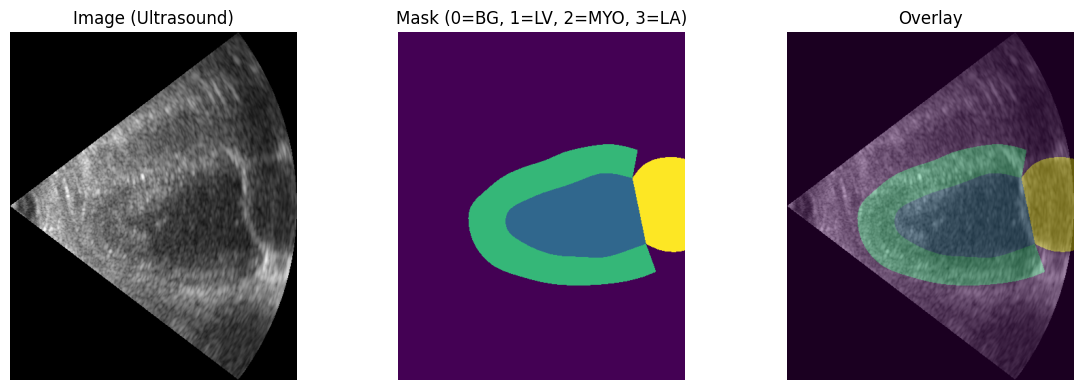

Sample file: patient0211_4CH_ES.nii.gz
Unique labels: [0. 1. 2. 3.]


In [ ]:
idx = random.randint(0, len(images)-1)

img = nib.load(images[idx]).get_fdata()
msk = nib.load(masks[idx]).get_fdata()

if img.ndim == 3: img = img[:, :, 0]
if msk.ndim == 3: msk = msk[:, :, 0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image (Ultrasound)")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask (0=BG, 1=LV, 2=MYO, 3=LA)")
plt.imshow(msk)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(img, cmap="gray")
plt.imshow(msk, alpha=0.4)
plt.axis("off")

plt.tight_layout()
plt.show()

print("Sample file:", os.path.basename(images[idx]))
print("Unique labels:", np.unique(msk))

Pixel counts (subset): Counter({0: 82343721, 1: 8611328, 2: 8507561, 3: 4995280})


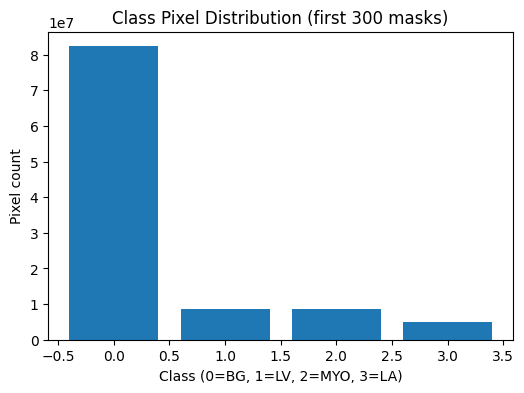

In [ ]:
from collections import Counter

N = min(300, len(masks))
counter = Counter()

for mpath in masks[:N]:
    m = nib.load(mpath).get_fdata()
    if m.ndim == 3:
        m = m[:, :, 0]
    uniq, cnt = np.unique(m.astype(np.int64), return_counts=True)
    for u, c in zip(uniq, cnt):
        counter[int(u)] += int(c)

print("Pixel counts (subset):", counter)

plt.figure(figsize=(6,4))
plt.bar(counter.keys(), counter.values())
plt.title(f"Class Pixel Distribution (first {N} masks)")
plt.xlabel("Class (0=BG, 1=LV, 2=MYO, 3=LA)")
plt.ylabel("Pixel count")
plt.show()

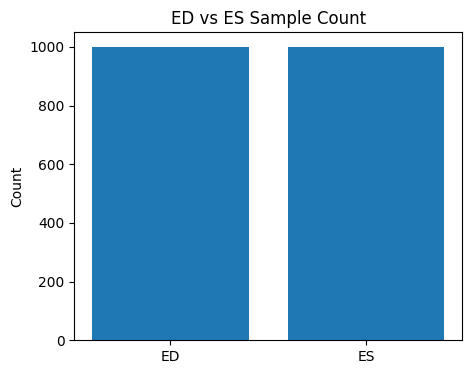

ED: 1000 ES: 1000


In [ ]:
ed_count = sum("_ED.nii.gz" in p for p in images)
es_count = sum("_ES.nii.gz" in p for p in images)

plt.figure(figsize=(5,4))
plt.bar(["ED", "ES"], [ed_count, es_count])
plt.title("ED vs ES Sample Count")
plt.ylabel("Count")
plt.show()

print("ED:", ed_count, "ES:", es_count)

In [ ]:
class CamusNiftiDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # faster than get_fdata() sometimes
        img = np.asanyarray(nib.load(self.image_paths[idx]).dataobj)
        msk = np.asanyarray(nib.load(self.mask_paths[idx]).dataobj)

        if img.ndim == 3: img = img[:, :, 0]
        if msk.ndim == 3: msk = msk[:, :, 0]

        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        msk = cv2.resize(msk, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        msk = msk.astype(np.int64)  # keep 0/1/2/3

        if self.transform:
            out = self.transform(image=img.astype(np.float32), mask=msk)
            img = out["image"]
            msk = out["mask"].long()

        return img.float(), msk

In [ ]:
transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

dataset = CamusNiftiDataset(images, masks, transform=transform, size=IMAGE_SIZE)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train:", len(train_ds), "Val:", len(val_ds))
print("Batch size:", BATCH_SIZE)

Train: 1600 Val: 400
Batch size: 4


In [ ]:
def model_unet():      # Paper 1 baseline + Paper 5 baseline
    return smp.Unet("resnet34", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

def model_deeplab():   # Paper 2 backbone
    return smp.DeepLabV3("resnet34", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

def model_resunet():   # Paper 4 backbone
    return smp.Unet("resnet50", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

In [ ]:
def soft_dice_loss(logits, targets, num_classes=NUM_CLASSES, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    targets_oh = torch.nn.functional.one_hot(targets, num_classes).permute(0,3,1,2).float()

    dims = (0,2,3)
    intersection = torch.sum(probs * targets_oh, dims)
    union = torch.sum(probs + targets_oh, dims)

    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice[1:].mean()  # ignore background

class CEPlusDice(nn.Module):
    def __init__(self, ce_weight=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.ce_weight = ce_weight

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + (1 - self.ce_weight) * soft_dice_loss(logits, targets)

In [ ]:
def dice_iou_for_class(pred, true, cls, eps=1e-8):
    pred_c = (pred == cls)
    true_c = (true == cls)
    inter = (pred_c & true_c).sum()
    dice = (2*inter) / (pred_c.sum() + true_c.sum() + eps)
    iou  = inter / (pred_c.sum() + true_c.sum() - inter + eps)
    return float(dice), float(iou)

def evaluate_fast(model, loader):
    model.eval()
    dices = {1: [], 2: [], 3: []}
    ious  = {1: [], 2: [], 3: []}

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            true = y.cpu().numpy()

            for b in range(pred.shape[0]):
                for cls in [1, 2, 3]:
                    d, i = dice_iou_for_class(pred[b], true[b], cls)
                    dices[cls].append(d)
                    ious[cls].append(i)

    return {
        "Dice_LV": np.mean(dices[1]),
        "Dice_MYO": np.mean(dices[2]),
        "Dice_LA": np.mean(dices[3]),
        "IoU_LV": np.mean(ious[1]),
        "IoU_MYO": np.mean(ious[2]),
        "IoU_LA": np.mean(ious[3]),
    }

def evaluate_hd95_only(model, loader):
    model.eval()
    hds = {1: [], 2: [], 3: []}

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            true = y.cpu().numpy()

            for b in range(pred.shape[0]):
                for cls in [1, 2, 3]:
                    try:
                        if (pred[b] == cls).any() and (true[b] == cls).any():
                            hds[cls].append(
                                hd95((pred[b] == cls).astype(np.uint8),
                                     (true[b] == cls).astype(np.uint8))
                            )
                    except:
                        pass

    return {
        "HD95_LV": np.mean(hds[1]) if len(hds[1]) else np.nan,
        "HD95_MYO": np.mean(hds[2]) if len(hds[2]) else np.nan,
        "HD95_LA": np.mean(hds[3]) if len(hds[3]) else np.nan,
    }

In [ ]:
import copy
import numpy as np

def train_model_best(model, loss_fn, epochs=3, lr=LR, log_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_score = -1.0

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0

        print(f"\n>>> Epoch {ep}/{epochs} started")

        for bi, (x, y) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = loss_fn(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()

            if (bi + 1) % log_every == 0:
                print(f"    batch {bi+1}/{len(train_loader)} | loss {total_loss/(bi+1):.4f}")

        metrics = evaluate_fast(model, val_loader)
        score = float(np.mean([metrics["Dice_LV"], metrics["Dice_MYO"], metrics["Dice_LA"]]))

        print(
            f">>> Epoch {ep} finished | Loss {total_loss/len(train_loader):.4f} | "
            f"Dice(LV) {metrics['Dice_LV']:.4f} | Dice(MYO) {metrics['Dice_MYO']:.4f} | Dice(LA) {metrics['Dice_LA']:.4f} | "
            f"AvgDice {score:.4f}"
        )

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            print(f"     Best model saved (AvgDice {best_score:.4f})")

    model.load_state_dict(best_state)
    print(f"\n>>> Restored BEST epoch model | Best AvgDice: {best_score:.4f}")
    return model

In [ ]:
class_weights = torch.tensor([0.2, 1.0, 1.0, 1.3], device=device)  # BG, LV, MYO, LA
ce_weighted = nn.CrossEntropyLoss(weight=class_weights)

print("Weighted CE ready:", class_weights)

Weighted CE ready: tensor([0.2000, 1.0000, 1.0000, 1.3000], device='cuda:0')


In [ ]:
torch.cuda.empty_cache()

EPOCHS = 3  # later change to 20 for final dissertation
results = {}

def run_one(name, model_fn, loss_fn):
    print(f"\n====================\n>>> Starting {name}\n====================")
    torch.cuda.empty_cache()

    m = model_fn()
    m = train_model_best(m, loss_fn, epochs=EPOCHS, log_every=100)

    print(f">>> {name} training done. Computing FAST metrics...")
    res = evaluate_fast(m, val_loader)

    print(f">>> {name} computing HD95 (slow)...")
    res.update(evaluate_hd95_only(m, val_loader))

    results[name] = res
    return m

# Paper 1 — UNet (weighted CE recommended)
m1 = run_one("Paper1_UNet", model_unet, ce_weighted)

# Paper 2 — DeepLabV3 (weighted CE recommended)
m2 = run_one("Paper2_DeepLabV3", model_deeplab, ce_weighted)

# Paper 3 — UNet + CE+Dice (keep as-is)
m3 = run_one("Paper3_UNet_CE+Dice", model_unet, CEPlusDice(0.5))

# Paper 4 — ResUNet (weighted CE recommended)
m4 = run_one("Paper4_ResUNet", model_resunet, ce_weighted)

# Paper 5 — UNet baseline (weighted CE recommended)
m5 = run_one("Paper5_UNet_Baseline", model_unet, ce_weighted)

df = pd.DataFrame(results).T
df


>>> Starting Paper1_UNet

>>> Epoch 1/3 started
    batch 100/400 | loss 0.7248
    batch 200/400 | loss 0.5513
    batch 300/400 | loss 0.4627
    batch 400/400 | loss 0.4057
>>> Epoch 1 finished | Loss 0.4057 | Dice(LV) 0.9022 | Dice(MYO) 0.7779 | Dice(LA) 0.7768 | AvgDice 0.8190
    ✅ New best model saved (AvgDice 0.8190)

>>> Epoch 2/3 started
    batch 100/400 | loss 0.2046
    batch 200/400 | loss 0.1959
    batch 300/400 | loss 0.1931
    batch 400/400 | loss 0.1929
>>> Epoch 2 finished | Loss 0.1929 | Dice(LV) 0.3926 | Dice(MYO) 0.4235 | Dice(LA) 0.0931 | AvgDice 0.3031

>>> Epoch 3/3 started
    batch 100/400 | loss 0.1605
    batch 200/400 | loss 0.1597
    batch 300/400 | loss 0.1573
    batch 400/400 | loss 0.1552
>>> Epoch 3 finished | Loss 0.1552 | Dice(LV) 0.8996 | Dice(MYO) 0.8289 | Dice(LA) 0.8639 | AvgDice 0.8641
    ✅ New best model saved (AvgDice 0.8641)

>>> Restored BEST epoch model | Best AvgDice: 0.8641
>>> Paper1_UNet training done. Computing FAST metrics...
>

,Dice_LV,Dice_MYO,Dice_LA,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA
Paper1_UNet,0.899557,0.828909,0.863862,0.824151,0.714358,0.776167,9.277803,10.363394,10.154017
Paper2_DeepLabV3,0.894875,0.780526,0.836518,0.815359,0.647737,0.731880,8.926491,9.472720,11.293508
Paper3_UNet_CE+Dice,0.912690,0.841077,0.873632,0.851641,0.734086,0.794552,7.343429,8.681220,8.549873
Paper4_ResUNet,0.908957,0.762233,0.842350,0.838039,0.621836,0.742085,7.818364,13.259537,11.615230
Paper5_UNet_Baseline,0.910184,0.831760,0.859588,0.838653,0.715718,0.766005,7.264934,8.708062,10.287415


In [ ]:
df["Mean_Dice"] = df[["Dice_LV","Dice_MYO","Dice_LA"]].mean(axis=1)
df["Mean_HD95"] = df[["HD95_LV","HD95_MYO","HD95_LA"]].mean(axis=1)
df.sort_values("Mean_Dice", ascending=False)

,Dice_LV,Dice_MYO,Dice_LA,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA,Mean_Dice,Mean_HD95
Paper3_UNet_CE+Dice,0.912690,0.841077,0.873632,0.851641,0.734086,0.794552,7.343429,8.681220,8.549873,0.875800,8.191507
Paper5_UNet_Baseline,0.910184,0.831760,0.859588,0.838653,0.715718,0.766005,7.264934,8.708062,10.287415,0.867178,8.753470
Paper1_UNet,0.899557,0.828909,0.863862,0.824151,0.714358,0.776167,9.277803,10.363394,10.154017,0.864109,9.931738
Paper4_ResUNet,0.908957,0.762233,0.842350,0.838039,0.621836,0.742085,7.818364,13.259537,11.615230,0.837847,10.897710
Paper2_DeepLabV3,0.894875,0.780526,0.836518,0.815359,0.647737,0.731880,8.926491,9.472720,11.293508,0.837307,9.897573
